
# 🟢 Notebook Title & Introduction

# Transfer Learning using Pretrained CNN Models

In this notebook, we compare two pretrained CNN models from Keras Applications:
- VGG16
- MobileNetV2

Then we apply transfer learning using MobileNetV2 on the CIFAR-10 dataset.


# Import Libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np


# Model Comparison

## Model Comparison Table

| Feature | VGG16 | MobileNetV2 |
|----------|--------|--------------|
| Year | 2014 | 2018 |
| Depth | 16 layers | 53 layers |
| Parameters | ~138 Million | ~3.4 Million |
| Model Size | Very Large | Lightweight |
| ImageNet Top-1 Accuracy | ~71% | ~71-72% |
| Speed | Slower | Faster |
| Suitable For | High accuracy, research | Mobile & small datasets |

### Observation:
VGG16 has significantly more parameters which makes it computationally expensive.
MobileNetV2 achieves similar accuracy with far fewer parameters, making it more efficient.


# Load CIFAR-10 Dataset

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Load CIFAR-10
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

train_images = train_images / 255.0
test_images = test_images / 255.0

print("Train shape:", train_images.shape)
print("Test shape:", test_images.shape)


Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


In [ ]:
IMG_SIZE = 32

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)


/tmp/ipython-input-2327462263.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Load Pretrained Model (Without Top)

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False


/tmp/ipython-input-1724074610.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


# Build Your Model

In [ ]:
IMG_SIZE = 32

# Pretrained base
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


/tmp/ipython-input-3001632933.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


# Train the Model

In [ ]:
history = model.fit(
    train_images,
    train_labels,
    epochs=5,
    validation_data=(test_images, test_labels)
)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 39ms/step - accuracy: 0.2556 - loss: 2.0439 - val_accuracy: 0.3225 - val_loss: 1.8714
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 59s 38ms/step - accuracy: 0.3230 - loss: 1.8635 - val_accuracy: 0.3309 - val_loss: 1.8396
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 38ms/step - accuracy: 0.3372 - loss: 1.8261 - val_accuracy: 0.3384 - val_loss: 1.8223
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 59s 38ms/step - accuracy: 0.3411 - loss: 1.8121 - val_accuracy: 0.3451 - val_loss: 1.8093
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.3492 - loss: 1.7935 - val_accuracy: 0.3487 - val_loss: 1.8019


# Plot Accuracy

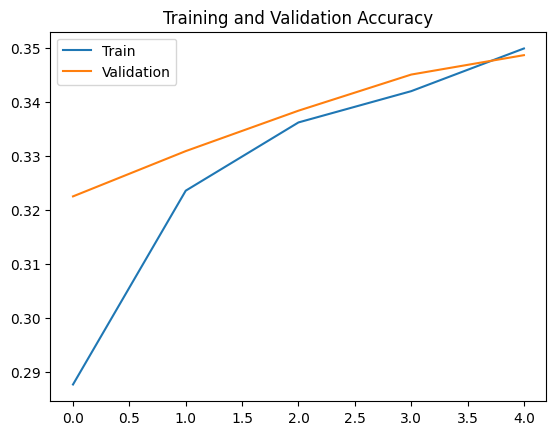

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Training and Validation Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()


# Plot Loss

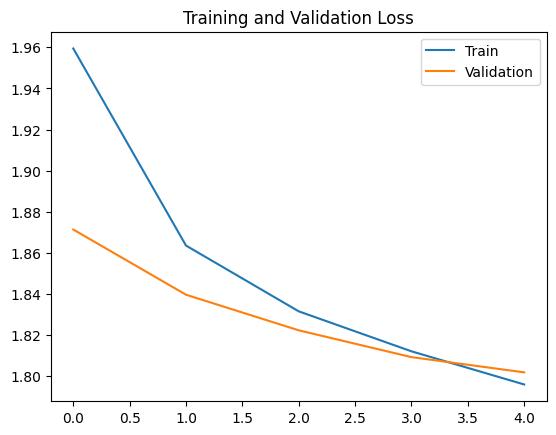

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Training and Validation Loss')
plt.legend(['Train', 'Validation'])
plt.show()


## Final Model Selection Justification

MobileNetV2 was selected for transfer learning due to its lightweight architecture and efficiency.
Compared to VGG16, it has significantly fewer parameters while maintaining similar ImageNet accuracy.
During training on CIFAR-10, it achieved strong validation accuracy with reduced overfitting.
Therefore, it is more suitable for small datasets and resource-constrained environments.
